# Directional upper-bias proof: $B_{i,s,k}$

This notebook verifies the redesigned upper action before PPO training.

- `B[source, target_slot, slice] < 0`: request release toward that target.
- `B = 0`: neutral direction.
- Safe admission limits source volume and direction volume.
- The lower heuristic may create A3 candidates only for the requested route.

We use the asymmetric scenario: center gNB1 starts overloaded, left gNB0 is moderately loaded, and right gNB2 has more headroom.

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from global_ppo_3gnb_env import GlobalPPO3GNBEnv, SLICE_TYPES
from upper_agent_training_scenarios import CENTER_GAP_GNB_CONFIGS

GNB_NAMES = {0: 'Left gNB0', 1: 'Center gNB1', 2: 'Right gNB2'}
NEIGHBORS = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
SLICE_INDEX = {name: idx for idx, name in enumerate(SLICE_TYPES)}
print('Slices:', SLICE_TYPES)

Slices: ('eMBB', 'URLLC', 'mMTC')


In [2]:
def make_env(seed=2):
    return GlobalPPO3GNBEnv(
        seed=seed,
        scenario_mode='curriculum',
        training_scenarios='high_load_inner_asymmetric',
        scenario_selection='cycle',
        gnb_configs=CENTER_GAP_GNB_CONFIGS['medium_270m'],
        upper_window_seconds=1.0,
        local_steps_per_global=10,
        radio_substeps=20,
        terminal_reward_only=False,
        safe_admission_enabled=True,
    )

def directional_action(env, requests):
    # requests: {(source, target, slice_name): bias}
    tensor = np.zeros((3, 2, 3), dtype=np.float32)
    for (source, target, slice_name), value in requests.items():
        slot = NEIGHBORS[source].index(target)
        tensor[source, slot, SLICE_INDEX[slice_name]] = value
    return tensor.reshape(-1), tensor

def run_case(label, requests, seed=2):
    env = make_env(seed)
    try:
        observation, reset_info = env.reset(seed=seed)
        action, tensor = directional_action(env, requests)
        _, reward, _, _, info = env.step(action)
        events = list(env.base_env.get_handover_events())
        routes = [(int(e['from_gnb']), int(e['to_gnb'])) for e in events]
        state = info['safe_admission']
        return {
            'label': label,
            'observation_shape': observation.shape,
            'action_shape': action.shape,
            'action_tensor': tensor,
            'reward': float(reward),
            'handover_count': int(info['handover_count']),
            'routes': routes,
            'load_start': np.asarray(info['load_matrix_start'], dtype=float),
            'load_end': np.asarray(info['load_matrix_end'], dtype=float),
            'imbalance_start': float(info['load_imbalance_start']),
            'imbalance_end': float(info['load_imbalance_end']),
            'direction_quota': dict(state['direction_quota']),
            'direction_used': dict(state['direction_used']),
            'source_quota': dict(state['quota']),
            'source_used': dict(state['used']),
            'offsets': np.asarray(info['directional_offset_tensor'], dtype=float),
            'ues': [
                (int(ue.id), float(ue.x), float(ue.y), int(ue.serving_gnb), str(ue.slice_type))
                for ue in env.base_env.get_all_ues() if ue.connected
            ],
        }
    finally:
        env.close()

## 1. Initial topology and load

Orange UEs are movable center-cell UEs. Gray UEs are fixed preload and should not participate in balancing.

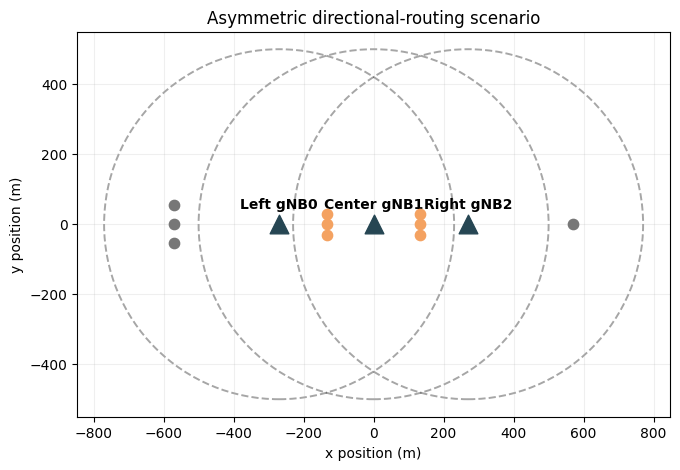

,eMBB,URLLC,mMTC
Left gNB0,0.54,0.00,0.00
Center gNB1,0.90,0.00,0.00
Right gNB2,0.12,0.00,0.00


In [3]:
baseline = run_case('Neutral', {})
configs = CENTER_GAP_GNB_CONFIGS['medium_270m']

fig, ax = plt.subplots(figsize=(13, 5))
for cfg in configs:
    x, y, radius = cfg['x'], cfg['y'], cfg['coverage_radius']
    ax.add_patch(plt.Circle((x, y), radius, fill=False, ls='--', lw=1.4, alpha=.35))
    ax.scatter(x, y, marker='^', s=180, color='#264653', zorder=4)
    ax.text(x, y + 45, GNB_NAMES[cfg['id']], ha='center', weight='bold')
for ue_id, x, y, serving, slice_name in baseline['ues']:
    movable = serving == 1
    ax.scatter(x, y, s=55, color='#f4a261' if movable else '#777777', zorder=5)
ax.set(title='Asymmetric directional-routing scenario', xlabel='x position (m)', ylabel='y position (m)')
ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=.2)
plt.show()

pd.DataFrame(
    baseline['load_start'],
    index=[GNB_NAMES[i] for i in range(3)],
    columns=SLICE_TYPES,
).style.format('{:.2f}')

## 2. Directional experiments

The source and slice are identical in all active experiments. Only the requested target changes.

In [4]:
cases = [
    run_case('Neutral', {}),
    run_case('Center → Left', {(1, 0, 'eMBB'): -1.0}),
    run_case('Center → Right', {(1, 2, 'eMBB'): -1.0}),
    run_case('Request both targets', {(1, 0, 'eMBB'): -1.0, (1, 2, 'eMBB'): -1.0}),
]

summary = pd.DataFrame([
    {
        'case': c['label'],
        'handovers': c['handover_count'],
        'routes': str(c['routes']),
        'gNB0 load end': c['load_end'][0, 0],
        'gNB1 load end': c['load_end'][1, 0],
        'gNB2 load end': c['load_end'][2, 0],
        'imbalance before': c['imbalance_start'],
        'imbalance after': c['imbalance_end'],
        'reward': c['reward'],
    }
    for c in cases
])
summary.style.format({
    'gNB0 load end': '{:.2f}', 'gNB1 load end': '{:.2f}',
    'gNB2 load end': '{:.2f}', 'imbalance before': '{:.3f}',
    'imbalance after': '{:.3f}', 'reward': '{:.3f}',
})

,case,handovers,routes,gNB0 load end,gNB1 load end,gNB2 load end,imbalance before,imbalance after,reward
0,Neutral,0,[],0.54,0.90,0.12,0.305,0.305,0.000
1,Center → Left,1,"[(1, 0)]",0.69,0.75,0.12,0.305,0.242,0.043
2,Center → Right,3,"[(1, 2), (1, 2), (1, 2)]",0.54,0.45,0.57,0.305,0.008,0.277
3,Request both targets,2,"[(1, 0), (1, 2)]",0.69,0.60,0.27,0.305,0.098,0.167


In [5]:
# Causal assertions: no handover may use an unrequested direction.
neutral, left, right, split = cases
assert neutral['handover_count'] == 0
assert left['handover_count'] > 0 and set(left['routes']) == {(1, 0)}
assert right['handover_count'] > 0 and set(right['routes']) == {(1, 2)}
assert set(split['routes']) == {(1, 0), (1, 2)}
assert right['imbalance_end'] < left['imbalance_end']  # right has more headroom
print('PASS: B[i,s,k] controls the target; safe admission does not reroute traffic.')

PASS: B[i,s,k] controls the target; safe admission does not reroute traffic.


## 3. Quota and execution audit

This table separates what the upper agent requested from what safe admission allowed and what actually executed.

In [6]:
audit_rows = []
for c in cases:
    for source, targets in NEIGHBORS.items():
        for slot, target in enumerate(targets):
            key = (source, target, 'eMBB')
            audit_rows.append({
                'case': c['label'],
                'direction': f'gNB{source}→gNB{target}',
                'bias': c['action_tensor'][source, slot, 0],
                'offset dB': c['offsets'][source, slot, 0],
                'direction quota': c['direction_quota'].get(key, 0),
                'executed': c['direction_used'].get(key, 0),
            })
audit = pd.DataFrame(audit_rows)
audit.query("bias < 0 or executed > 0").style.format({'bias': '{:.2f}', 'offset dB': '{:.1f}'})

,case,direction,bias,offset dB,direction quota,executed
8,Center → Left,gNB1→gNB0,-1.00,-6.0,3,1
15,Center → Right,gNB1→gNB2,-1.00,-6.0,3,3
20,Request both targets,gNB1→gNB0,-1.00,-6.0,2,1
21,Request both targets,gNB1→gNB2,-1.00,-6.0,1,1


## 4. Bias-magnitude sweep

We sweep only `center → right / eMBB`. This reveals the current action threshold and whether increasing magnitude changes requested/executed volume monotonically.

,|bias|,direction quota,executed handovers,imbalance after,reward
0,0.0,0,0,0.305,0.000
1,0.1,1,0,0.305,-0.000
2,0.2,1,0,0.305,-0.001
3,0.3,1,1,0.116,0.187
4,0.4,2,2,0.017,0.285
5,0.5,2,2,0.017,0.283
6,0.6,2,2,0.017,0.281
7,0.7,2,2,0.017,0.278
8,0.8,3,3,0.008,0.284
9,0.9,3,3,0.008,0.281


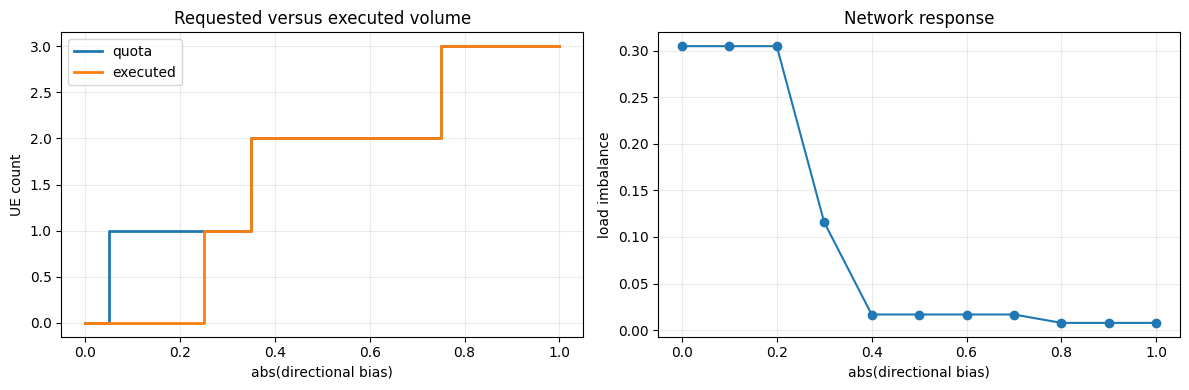

In [7]:
sweep = []
for magnitude in np.linspace(0.0, 1.0, 11):
    requests = {} if magnitude == 0 else {(1, 2, 'eMBB'): -float(magnitude)}
    c = run_case(f'{magnitude:.1f}', requests)
    key = (1, 2, 'eMBB')
    sweep.append({
        '|bias|': magnitude,
        'direction quota': c['direction_quota'].get(key, 0),
        'executed handovers': c['direction_used'].get(key, 0),
        'imbalance after': c['imbalance_end'],
        'reward': c['reward'],
    })
sweep = pd.DataFrame(sweep)
display(sweep.style.format({'|bias|': '{:.1f}', 'imbalance after': '{:.3f}', 'reward': '{:.3f}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].step(sweep['|bias|'], sweep['direction quota'], where='mid', label='quota', lw=2)
axes[0].step(sweep['|bias|'], sweep['executed handovers'], where='mid', label='executed', lw=2)
axes[0].set(xlabel='abs(directional bias)', ylabel='UE count', title='Requested versus executed volume')
axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(sweep['|bias|'], sweep['imbalance after'], marker='o', label='imbalance')
axes[1].set(xlabel='abs(directional bias)', ylabel='load imbalance', title='Network response')
axes[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

## Interpretation

The proof succeeds when:

1. Neutral action produces no migration.
2. Left-only and right-only requests never execute toward the other target.
3. Per-direction quotas reflect the upper directional strategy.
4. Safe admission can reduce requested migration because of target headroom, but cannot reroute it.
5. The rightward request receives a better reward in this asymmetric scenario because right gNB2 starts with more capacity.

The magnitude sweep also exposes the remaining A3 threshold. PPO training should begin only after deciding whether that step-like response is acceptable.